## Setup

In [1]:
# import necessary libraries
import time
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer

In [36]:
# load paths
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.evaluation import calculate_macro_f1
from src.submission import create_submission

DATA_DIR = PROJECT_ROOT / "data"
SUBMISSIONS_DIR = PROJECT_ROOT / "submissions"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train_features.csv"
TEST_PATH = DATA_DIR / "test_features.csv"
SPLIT_PATH = DATA_DIR / "splits" / "shared_validation_split.csv"

print(TRAIN_PATH.exists(), TEST_PATH.exists(), SPLIT_PATH.exists())

True True True


In [56]:
# load raw data + shared split
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

ID_COLUMN = "id"
LABEL_COLUMN = "label"

FEATURES = [c for c in train_df.columns if c not in (ID_COLUMN, LABEL_COLUMN)]
assert len(FEATURES) == 5000, f"expected 5000 features, got {len(FEATURES)}"

split = pd.read_csv(SPLIT_PATH)
assert len(split) == len(train_df)

split = split.set_index("row_index")
is_train = (split.loc[train_df.index, "split"] == "train").to_numpy()

X_train = train_df.loc[is_train, FEATURES].to_numpy(dtype=np.float32)
X_val = train_df.loc[~is_train, FEATURES].to_numpy(dtype=np.float32)
y_train = train_df.loc[is_train, LABEL_COLUMN].to_numpy()
y_val = train_df.loc[~is_train, LABEL_COLUMN].to_numpy()

X_train = np.ascontiguousarray(X_train, dtype=np.float32)
X_val = np.ascontiguousarray(X_val, dtype=np.float32)
print(X_train.flags['C_CONTIGUOUS'], X_val.flags['C_CONTIGUOUS'])

print(X_train.shape, X_val.shape)
print(round(y_train.mean(), 4), round(y_val.mean(), 4))

True True
(16000, 5000) (4000, 5000)
0.6252 0.6252


# Multinomial Naive Baynes Model

In [39]:
# Multinomial Naive Bayes from scratch
def nb_fit(X, y, alpha=1.0):
    classes = np.unique(y)
    n_classes = len(classes)
    n_features = X.shape[1]

    class_log_prior = np.zeros(n_classes)
    feature_log_prob = np.zeros((n_classes, n_features))

    for idx, c in enumerate(classes):
        X_c = X[y == c]  
        class_log_prior[idx] = np.log(X_c.shape[0] / X.shape[0])

        feature_mass = np.asarray(X_c.sum(axis=0)).ravel() + alpha 
        total_mass = feature_mass.sum()
        feature_log_prob[idx] = np.log(feature_mass / total_mass)

    return classes, class_log_prior, feature_log_prob

In [40]:
# predict
def nb_predict_log_proba(X, class_log_prior, feature_log_prob):
    return X @ feature_log_prob.T + class_log_prior


def nb_predict(X, classes, class_log_prior, feature_log_prob):
    log_proba = nb_predict_log_proba(X, class_log_prior, feature_log_prob)
    return classes[np.argmax(log_proba, axis=1)]


def nb_predict_proba(X, class_log_prior, feature_log_prob):
    log_proba = nb_predict_log_proba(X, class_log_prior, feature_log_prob)
    log_proba -= log_proba.max(axis=1, keepdims=True)
    proba = np.exp(log_proba)
    return proba / proba.sum(axis=1, keepdims=True)

In [128]:
# baseline model
classes, class_log_prior, feature_log_prob = nb_fit(X_train, y_train, alpha=1.0)
val_preds = nb_predict(X_val, classes, class_log_prior, feature_log_prob)

baseline_f1 = calculate_macro_f1(y_val, val_preds) 
print("baseline (alpha=1.0) val Macro F1:", round(baseline_f1, 6))

baseline (alpha=1.0) val Macro F1: 0.660464


In [129]:
# testing different 'alpha' parameter values
results = []

for alpha in [0.01, 0.1, 0.5, 1, 2]:
    t0 = time.time()
    classes, class_log_prior, feature_log_prob = nb_fit(X_train, y_train, alpha=alpha)
    preds = nb_predict(X_val, classes, class_log_prior, feature_log_prob)
    score = calculate_macro_f1(y_val, preds)
    results.append({
        "alpha": alpha,
        "val_macro_f1": score,
        "runtime_s": round(time.time() - t0, 2),
    })
    
results_df = (pd.DataFrame(results)
              .sort_values("val_macro_f1", ascending=False)
              .reset_index(drop=True))
results_df.to_csv(PROJECT_ROOT / "reports" / "nb_tuning_results.csv", index=False)
results_df

,alpha,val_macro_f1,runtime_s
0,0.01,0.673634,0.25
1,0.10,0.671927,0.26
2,0.50,0.667952,0.25
3,1.00,0.660464,0.24
4,2.00,0.636222,0.42


In [130]:
# choose model with best parameters
best_alpha = float(results_df.iloc[0].alpha)
print("best alpha:", best_alpha, "val Macro F1:", round(float(results_df.iloc[0].val_macro_f1), 6))

best alpha: 0.01 val Macro F1: 0.673634


In [131]:
# refit model on all labelled data 
X_full = np.concatenate([X_train, X_val], axis=0)
y_full = np.concatenate([y_train, y_val], axis=0)

final_classes, final_class_log_prior, final_feature_log_prob = nb_fit(X_full, y_full, alpha=best_alpha)

In [132]:
X_test = test_df[FEATURES].to_numpy(dtype=np.float32)
test_preds = nb_predict(X_test, final_classes, final_class_log_prior, final_feature_log_prob)

print(pd.Series(test_preds).value_counts().sort_index())

X_full = np.ascontiguousarray(X_full, dtype=np.float32)
X_test = np.ascontiguousarray(X_test, dtype=np.float32)
print(X_full.shape, X_test.shape)

0     883
1    6116
dtype: int64
(20000, 5000) (6999, 5000)


In [134]:
# save data 
nb_submission_path = SUBMISSIONS_DIR / "NB_updated_Prediction.csv"
nb_submission_df = create_submission(
    test_ids=test_df[ID_COLUMN],
    predictions=test_preds,
    output_path=nb_submission_path,
    id_column=ID_COLUMN,
    label_column=LABEL_COLUMN,
)
display(nb_submission_df.head())

,id,label
0,59218,1
1,37110,1
2,23200,1
3,e3357348-166e-4847-a06d-158b7cd83aa5,1
4,61615,1


In [135]:
saved = pd.read_csv(nb_submission_path, dtype={ID_COLUMN: "string"})
expected_ids = test_df[ID_COLUMN].astype("string").reset_index(drop=True)

assert saved.columns.tolist() == [ID_COLUMN, LABEL_COLUMN]
assert len(saved) == len(test_df)
assert saved[ID_COLUMN].tolist() == expected_ids.tolist()
assert saved[LABEL_COLUMN].isnull().sum() == 0
assert set(saved[LABEL_COLUMN].unique()).issubset(set(train_df[LABEL_COLUMN].unique()))

print("verified - ready to upload")

verified - ready to upload


# SGD Model

In [49]:
# SGD linear classifier
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def compute_grad_f(f, y, loss):
    if loss == "log_loss":
        p = sigmoid(f)
        return p - y  
    y_signed = 2 * y - 1 
    margin = y_signed * f
    if loss == "hinge":
        grad_margin = np.where(margin < 1, -1.0, 0.0)
    elif loss == "modified_huber":
        grad_margin = np.where(
            margin <= -1, -4.0,
            np.where(margin >= 1, 0.0, -2.0 * (1 - margin))
        )
    else:
        raise ValueError(f"unsupported loss: {loss}")
    return grad_margin * y_signed


def reg_gradient(w, penalty, alpha, l1_ratio=0.15):
    if penalty == "l2":
        return alpha * w
    if penalty == "l1":
        return alpha * np.sign(w)
    if penalty == "elasticnet":
        return alpha * (l1_ratio * np.sign(w) + (1 - l1_ratio) * w)
    raise ValueError(f"unsupported penalty: {penalty}")

def hinge_loss_value(f, y):
    y_signed = 2 * y - 1
    margin = y_signed * f
    return np.mean(np.maximum(0, 1 - margin))

In [71]:
def sgd_fit(X, y, loss="hinge", penalty="l2", alpha=0.0001, l1_ratio=0.15,
            lr=0.01, epochs=20, bs=256, class_weight=None, random_state=42,
            X_val=None, y_val=None):
    rng = np.random.default_rng(random_state)
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0

    if class_weight == "balanced":
        classes, counts = np.unique(y, return_counts=True)
        weight_map = {c: m / (len(classes) * cnt) for c, cnt in zip(classes, counts)}
        sample_weight = np.array([weight_map[label] for label in y])
    else:
        sample_weight = np.ones(m)

    n_batches = (m - 1) // bs + 1
    losses = []
    val_f1_history = []

    best_val_f1 = -1.0 
    best_w, best_b = w.copy(), b 

    for epoch in range(epochs):
        order = rng.permutation(m)
        for i in range(n_batches):
            batch_idx = order[i * bs:(i + 1) * bs]
            Xb = X[batch_idx]
            yb = y[batch_idx]
            swb = sample_weight[batch_idx]

            f = np.asarray(Xb @ w).ravel() + b
            grad_f = compute_grad_f(f, yb, loss) * swb

            dw = np.asarray(Xb.T @ grad_f).ravel() / len(batch_idx) + reg_gradient(w, penalty, alpha, l1_ratio)
            db = grad_f.mean()

            w -= lr * dw
            b -= lr * db

        f_full = np.asarray(X @ w).ravel() + b
        if loss == "hinge":
            losses.append(hinge_loss_value(f_full, y))
        elif loss == "log_loss":
            p = np.clip(sigmoid(f_full), 1e-15, 1 - 1e-15)
            losses.append(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))
        else:
            losses.append(np.mean(np.abs(compute_grad_f(f_full, y, loss))))

        if X_val is not None and y_val is not None:
            val_preds_epoch = sgd_predict(X_val, w, b)
            current_f1 = calculate_macro_f1(y_val, val_preds_epoch)
            val_f1_history.append(current_f1)
            if current_f1 > best_val_f1:
                best_val_f1 = current_f1
                best_w, best_b = w.copy(), b

    if X_val is not None and y_val is not None:
        return best_w, best_b, losses, val_f1_history  
    else:
        return w, b, losses, val_f1_history  

In [ ]:
# predict
def sgd_predict(X, w, b):
    f = np.asarray(X @ w).ravel() + b
    return (f >= 0).astype(int)


def sgd_decision_function(X, w, b):
    return np.asarray(X @ w).ravel() + b


def sgd_predict_proba(X, w, b, loss):
    f = sgd_decision_function(X, w, b)
    if loss == "log_loss":
        p1 = sigmoid(f)
    elif loss == "modified_huber":
        p1 = np.clip((f + 1) / 2, 0, 1) 
    else:
        raise ValueError("hinge loss has no predict_proba - use sgd_decision_function instead")
    return np.column_stack([1 - p1, p1])

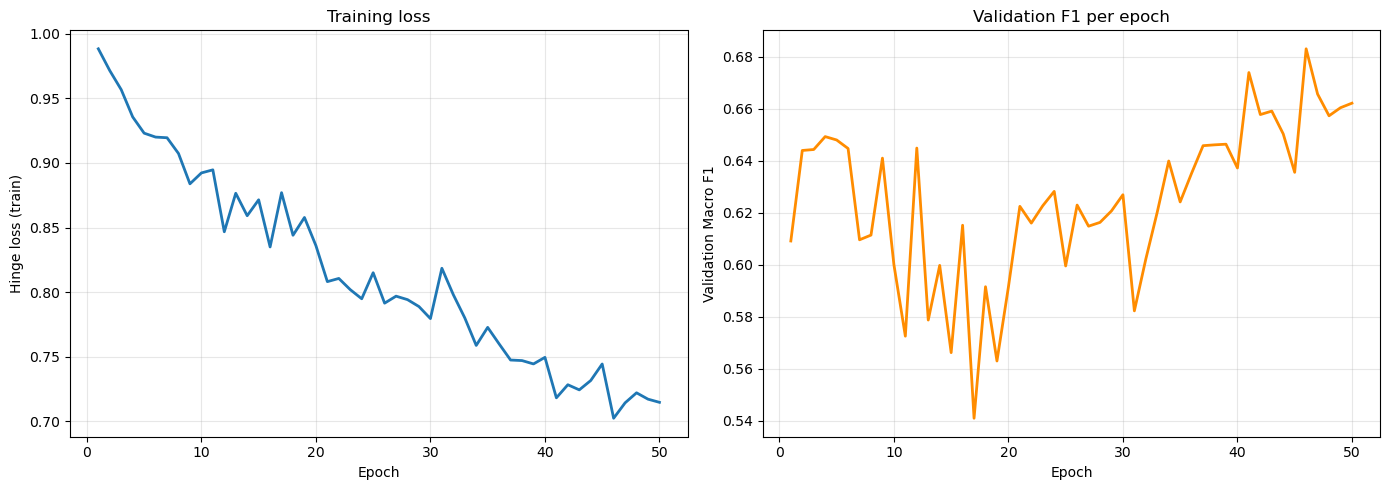

val F1 first 3: [0.6092, 0.644, 0.6443]
val F1 last 3: [0.6573, 0.6604, 0.6622]


In [119]:
# check convergence
w_check, b_check, losses_check, val_f1_check = sgd_fit(
    X_train, y_train, loss="hinge", penalty="l2", alpha=0.0001,
    lr=0.5, epochs=50, bs=256, class_weight="balanced",
    X_val=X_val, y_val=y_val
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(losses_check) + 1), losses_check, linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Hinge loss (train)")
axes[0].set_title("Training loss")
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(val_f1_check) + 1), val_f1_check, linewidth=2, color="darkorange")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Macro F1")
axes[1].set_title("Validation F1 per epoch")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "sgd_convergence_check.png", dpi=150)
plt.show()

print("val F1 first 3:", [round(f, 4) for f in val_f1_check[:3]])
print("val F1 last 3:", [round(f, 4) for f in val_f1_check[-3:]])

In [88]:
# choosing best loss result
loss_results = []
for loss_name in ["hinge", "modified_huber", "log_loss"]:
    t0 = time.time()
    w, b, _, _ = sgd_fit(X_train, y_train, loss=loss_name, penalty="l2", alpha=0.0001,
                         class_weight="balanced", lr=0.5, epochs=50)
    preds = sgd_predict(X_val, w, b)
    score = calculate_macro_f1(y_val, preds)
    loss_results.append({"loss": loss_name, "val_macro_f1": score, "runtime_s": round(time.time()-t0, 1)})
    print(f"loss={loss_name:<15} F1={score:.6f}")

loss_results_df = pd.DataFrame(loss_results).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
loss_results_df

loss=hinge           F1=0.662154
loss=modified_huber  F1=0.735821
loss=log_loss        F1=0.676461


,loss,val_macro_f1,runtime_s
0,modified_huber,0.735821,43.5
1,log_loss,0.676461,40.2
2,hinge,0.662154,43.5


In [89]:
# choosing best 'alpha' parameter result
BEST_LOSS = loss_results_df.iloc[0]["loss"]

alpha_results = []
for alpha in [0.00001, 0.0001, 0.001, 0.01]:
    t0 = time.time()
    w, b, _, _ = sgd_fit(X_train, y_train, loss=BEST_LOSS, penalty="l2", alpha=alpha,
                         class_weight="balanced", lr=0.5, epochs=50)
    preds = sgd_predict(X_val, w, b)
    score = calculate_macro_f1(y_val, preds)
    alpha_results.append({"alpha": alpha, "val_macro_f1": score, "runtime_s": round(time.time()-t0, 1)})
    print(f"alpha={alpha:<10} F1={score:.6f}")

alpha_results_df = pd.DataFrame(alpha_results).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
alpha_results_df

alpha=1e-05      F1=0.736909
alpha=0.0001     F1=0.735821
alpha=0.001      F1=0.721054
alpha=0.01       F1=0.659932


,alpha,val_macro_f1,runtime_s
0,0.00001,0.736909,45.0
1,0.00010,0.735821,58.5
2,0.00100,0.721054,43.7
3,0.01000,0.659932,42.0


In [90]:
# choosing best penality result
BEST_ALPHA = float(alpha_results_df.iloc[0]["alpha"])

penalty_results = []
for penalty in ["l1", "l2", "elasticnet"]:
    t0 = time.time()
    w, b, _, _ = sgd_fit(X_train, y_train, loss=BEST_LOSS, penalty=penalty, alpha=BEST_ALPHA,
                         class_weight="balanced", lr=0.5, epochs=50)
    preds = sgd_predict(X_val, w, b)
    score = calculate_macro_f1(y_val, preds)
    penalty_results.append({"penalty": penalty, "val_macro_f1": score, "runtime_s": round(time.time()-t0, 1)})
    print(f"penalty={penalty:<12} F1={score:.6f}")

penalty_results_df = pd.DataFrame(penalty_results).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
penalty_results_df

penalty=l1           F1=0.737509
penalty=l2           F1=0.736909
penalty=elasticnet   F1=0.736866


,penalty,val_macro_f1,runtime_s
0,l1,0.737509,40.7
1,l2,0.736909,40.0
2,elasticnet,0.736866,40.0


In [ ]:
# choosing best class-weight result
BEST_PENALTY = penalty_results_df.iloc[0]["penalty"]

class_weight_results = []
for cw in [None, "balanced"]:
    t0 = time.time()
    w, b, _, _ = sgd_fit(X_train, y_train, loss=BEST_LOSS, penalty=BEST_PENALTY, alpha=BEST_ALPHA,
                       class_weight=cw, lr=0.5, epochs=100)
    preds = sgd_predict(X_val, w, b)
    score = calculate_macro_f1(y_val, preds)
    class_weight_results.append({
        "class_weight": "None" if cw is None else cw,
        "val_macro_f1": score,
        "runtime_s": round(time.time()-t0, 1),
    })
    print(f"class_weight={cw} F1={score:.6f}")

class_weight_results_df = pd.DataFrame(class_weight_results).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
class_weight_results_df

class_weight=None F1=0.734392
class_weight=balanced F1=0.742274


,class_weight,val_macro_f1,runtime_s
0,balanced,0.742274,85.8
1,None,0.734392,84.4


In [92]:
# build model using best parameters
BEST_CLASS_WEIGHT = class_weight_results_df.iloc[0]["class_weight"]
BEST_CLASS_WEIGHT = None if BEST_CLASS_WEIGHT == "None" else BEST_CLASS_WEIGHT

In [93]:
# feature transform (NB-SVM)
def compute_nbsvm_ratio(X, y, alpha=1.0):
    X_pos = X[y == 1]
    X_neg = X[y == 0]

    p = X_pos.sum(axis=0) + alpha
    q = X_neg.sum(axis=0) + alpha

    p_norm = p / np.sum(np.abs(p))
    q_norm = q / np.sum(np.abs(q))

    r = np.log(p_norm / q_norm)
    return r


def apply_nbsvm_ratio(X, r):
    return X * r 

In [94]:
r = compute_nbsvm_ratio(X_train, y_train, alpha=1.0)

X_train_nbsvm = apply_nbsvm_ratio(X_train, r)
X_val_nbsvm = apply_nbsvm_ratio(X_val, r)

w_nbsvm, b_nbsvm, losses_nbsvm, val_f1_nbsvm = sgd_fit(
    X_train_nbsvm, y_train,
    loss=BEST_LOSS, penalty=BEST_PENALTY, alpha=BEST_ALPHA, class_weight=BEST_CLASS_WEIGHT,
    lr=0.5, epochs=100,
    X_val=X_val_nbsvm, y_val=y_val
)

print("NB-SVM val F1 (best epoch):", round(max(val_f1_nbsvm), 4))

NB-SVM val F1 (best epoch): 0.7158


In [136]:
final_w, final_b, _, _ = sgd_fit(
    X_full, y_full,
    loss=BEST_LOSS, penalty=BEST_PENALTY, alpha=BEST_ALPHA, class_weight=BEST_CLASS_WEIGHT,
    lr=0.5, epochs=100
)

sgd_test_preds = sgd_predict(X_test, final_w, final_b)

In [137]:
# save data
sgd_submission_path = SUBMISSIONS_DIR / "SGD_updated_Prediction.csv"
sgd_submission_df = create_submission(
    test_ids=test_df[ID_COLUMN],
    predictions=sgd_test_preds,
    output_path=sgd_submission_path,
    id_column=ID_COLUMN,
    label_column=LABEL_COLUMN,
)

display(sgd_submission_df.head())

,id,label
0,59218,1
1,37110,1
2,23200,0
3,e3357348-166e-4847-a06d-158b7cd83aa5,1
4,61615,0


In [138]:
saved = pd.read_csv(sgd_submission_path, dtype={ID_COLUMN: "string"})
expected_ids = test_df[ID_COLUMN].astype("string").reset_index(drop=True)

assert saved.columns.tolist() == [ID_COLUMN, LABEL_COLUMN]
assert len(saved) == len(test_df)
assert saved[ID_COLUMN].tolist() == expected_ids.tolist()
assert saved[LABEL_COLUMN].isnull().sum() == 0
assert set(saved[LABEL_COLUMN].unique()).issubset(set(train_df[LABEL_COLUMN].unique()))

print("verified - ready to upload")

verified - ready to upload
